# Notebook 4.5 — Avaliação Paciente-Específica — Deep Learning

Equivalente ao Notebook 3.5, mas com modelos de aprendizado profundo. Serve como verificação de integridade do pipeline de DL antes de avaliar generalização nos cenários A, B e C do Notebook 5.

## Protocolo

Idêntico ao NB3.5: treino e teste no **mesmo paciente**, separação cronológica, distribuição natural no teste, limiar de Youden no treino. As métricas são as mesmas para comparação direta.

## Modelos

| Modelo | Descrição |
|---|---|
| **1D-CNN** | Convolução temporal direta sobre o vetor de features. Captura padrões locais. |
| **CNN-LSTM** | CNN extrai features locais, LSTM captura dependência temporal entre janelas consecutivas dentro do mesmo arquivo. |
| **TCN** | Temporal Convolutional Network com convoluções dilatadas. Melhor relação desempenho/custo para sinais longos; indicado pela literatura para EEG vestível. |

## Interpretabilidade (aplicada ao modelo vencedor)

- **Grad-CAM 1D**: destaca quais features da janela mais ativam a predição de pré-ictal. Análogo ao Grad-CAM para imagens, adaptado para entrada 1D.
- **Attention Map**: para o CNN-LSTM com camada de atenção, mostra quais posições temporais o modelo priorizou.
- **Curvas de loss e acurácia por época**: detecta overfitting (divergência entre treino e validação).


## 1. Dependências

In [11]:
%pip install -q torch torchvision tqdm numpy pandas matplotlib seaborn scikit-learn shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os

# Ativado para localizar a linha exata do erro CUDA assíncrono.
# Deixe ativo até o erro ser resolvido; depois pode comentar para recuperar velocidade.

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
import gc, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score,
                             precision_score, accuracy_score, roc_curve)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# ── Controle de hardware ──────────────────────────────────────────────────
# FORCE_CPU=True ignora a GPU mesmo se disponível. Use se a GPU travou o
# sistema anteriormente — CPU é mais lento mas não trava a máquina.
FORCE_CPU = False

if FORCE_CPU:
    DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Limita a fração de VRAM que o processo pode reservar (evita que um pico
# de alocação trave o driver gráfico do sistema inteiro). Ajuste conforme
# a VRAM da sua GPU; 0.5 = até 50% da memória total da placa.
if DEVICE.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(0.5, device=0)
    torch.cuda.empty_cache()

print(f'Dispositivo: {DEVICE}')

ROOT_DIR    = 'data'
FEAT_DIR    = os.path.join(ROOT_DIR, 'features')
RESULTS_DIR = os.path.join(ROOT_DIR, 'results')
FIG_DIR     = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

N_CONSEC      = 5
STEP_TEST_SEC = 15
EPOCHS        = 25     # early stopping decide o real; teto menor evita rodadas longas sem ganho
BATCH_SIZE    = 16     # mantido — baixo pico de VRAM por passo
INFER_BATCH   = 64     # batch de inferência, separado do batch de treino
LR            = 1e-3
PATIENCE      = 5      # early stopping mais agressivo — corta treino que já parou de melhorar
WEIGHT_DECAY  = 3e-4    # regularização L2 mais forte — combate overfitting em pacientes com poucos eventos
MAX_TRAIN_WINDOWS = 3000   # leve redução adicional de memória/tempo (era 4000)
VAL_FRAC      = 0.2     # fração do treino reservada para validação (split por bloco temporal, ver train_model)

LEVELS = ['R5','R3','R2','R1','R0']
PATIENTS = {
    'CHBMIT'  : ['chb01','chb03','chb04','chb05','chb06','chb07','chb08','chb10','chb11','chb12','chb13','chb14'],
    'Siena'   : ['PN01','PN03','PN05','PN06','PN07','PN09','PN10','PN11','PN12','PN13','PN14','PN16'],
    'Mendeley': ['p10','p11','p12','p13','p14','p15'],
    'SeizeIT2': ['sub-001','sub-002','sub-003','sub-004','sub-005','sub-006',
                 'sub-007','sub-008','sub-009','sub-010','sub-011','sub-012'],
}
LEVEL_DS = {
    'R5':['CHBMIT','Siena','Mendeley'], 'R3':['CHBMIT','Siena','Mendeley'],
    'R2':['CHBMIT','Siena','Mendeley'], 'R1':['CHBMIT','Siena','Mendeley'],
    'R0':['CHBMIT','Siena','Mendeley','SeizeIT2'],
}
N_FEAT_CH = 19
CHANNEL_N = {'R5':15,'R3':11,'R2':9,'R1':4,'R0':2}
MODELS_DL = ['CNN1D','CNNLSTM','TCN']
CSV_PS_DL = os.path.join(RESULTS_DIR, 'patient_specific_dl.csv')
print('Configuração carregada.')

Dispositivo: cuda
Configuração carregada.


## 1.5. Verificação de hardware

Confirma o dispositivo de execução (CPU ou GPU) antes de definir as arquiteturas. O treino em GPU é significativamente mais rápido para os modelos de Deep Learning deste notebook; em CPU ainda é viável, mas o tempo total de execução cresce bastante nos cenários A/B/C do Notebook 5.


In [13]:
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponível: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    print(f'GPU(s) detectada(s): {n_gpu}')
    for i in range(n_gpu):
        props = torch.cuda.get_device_properties(i)
        print(f'  [{i}] {props.name} | {props.total_memory/1e9:.1f} GB VRAM | CUDA capability {props.major}.{props.minor}')
    print(f'\nDispositivo selecionado: {DEVICE} -> {torch.cuda.get_device_name(0)}')
else:
    import multiprocessing
    print('Nenhuma GPU CUDA detectada — execução em CPU.')
    print(f'Núcleos de CPU disponíveis: {multiprocessing.cpu_count()}')
    print(f'Dispositivo selecionado: {DEVICE}')
    print('\nAviso: o treino em CPU é funcional, porém mais lento.')
    print('Os cenários A/B/C do Notebook 5 envolvem centenas de treinos;')
    print('considere reduzir EPOCHS ou usar uma máquina com GPU se o tempo for um problema.')

# Teste rápido de alocação no dispositivo selecionado
_test = torch.randn(64, 100).to(DEVICE)
_ = _test @ _test.T
print(f'\nTeste de alocação no dispositivo "{DEVICE}": OK')
del _test

# Configuração efetiva de memória/treino para esta execução
print(f'\nConfiguração de carga:')
print(f'  BATCH_SIZE (treino): {BATCH_SIZE}')
print(f'  INFER_BATCH (avaliação): {INFER_BATCH}')
print(f'  EPOCHS (máximo, com early stopping): {EPOCHS}')
print(f'  MAX_TRAIN_WINDOWS (teto por paciente): {MAX_TRAIN_WINDOWS}')
if DEVICE.type == 'cuda':
    print(f'  Limite de VRAM reservado: 50% da capacidade total da GPU')
print(f'\nSe a GPU travar o sistema novamente, defina FORCE_CPU = True')
print(f'na célula de configuração acima e reinicie o kernel.')

PyTorch: 2.11.0+cu128
CUDA disponível: True
GPU(s) detectada(s): 1
  [0] NVIDIA GeForce GTX 1650 | 4.3 GB VRAM | CUDA capability 7.5

Dispositivo selecionado: cuda -> NVIDIA GeForce GTX 1650

Teste de alocação no dispositivo "cuda": OK

Configuração de carga:
  BATCH_SIZE (treino): 16
  INFER_BATCH (avaliação): 64
  EPOCHS (máximo, com early stopping): 25
  MAX_TRAIN_WINDOWS (teto por paciente): 3000
  Limite de VRAM reservado: 50% da capacidade total da GPU

Se a GPU travar o sistema novamente, defina FORCE_CPU = True
na célula de configuração acima e reinicie o kernel.


## 2. Arquiteturas

In [14]:
# ── 1D-CNN ──────────────────────────────────────────────────────────────
class CNN1D(nn.Module):
    def __init__(self, n_features, n_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        # para Grad-CAM
        self.gradients = None
        self.activations = None

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        # x: (B, n_features) -> (B, 1, n_features)
        x = x.unsqueeze(1)
        for layer in list(self.conv.children())[:-1]:
            x = layer(x)
        # registrar hook para Grad-CAM na última camada conv
        # (só quando há gradiente habilitado, ex: fora de torch.no_grad())
        self.activations = x
        if x.requires_grad:
            x.register_hook(self.activations_hook)
        x = list(self.conv.children())[-1](x)  # pooling
        x = x.view(x.size(0), -1)
        return self.fc(x)

# ── CNN-LSTM com Atenção ──────────────────────────────────────────────────
class CNNLSTMAttention(nn.Module):
    '''Versão reduzida: menos canais e LSTM unidirecional para diminuir o
    pico de VRAM (LSTM bidirecional dobra a memória de estados internos).'''
    def __init__(self, n_features, n_channels):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 32, batch_first=True, bidirectional=False)
        self.attn = nn.Linear(32, 1)
        self.fc   = nn.Sequential(
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
        self.attn_weights = None   # guardado para visualização

    def forward(self, x):
        x = x.unsqueeze(1)                              # (B,1,F)
        x = self.cnn(x)                                 # (B,64,F)
        x = x.permute(0, 2, 1)                         # (B,F,64)
        x, _ = self.lstm(x)                             # (B,F,32)
        scores = self.attn(x).squeeze(-1)               # (B,F)
        weights = torch.softmax(scores, dim=1)          # (B,F)
        self.attn_weights = weights.detach().cpu()
        context = (weights.unsqueeze(-1) * x).sum(dim=1)  # (B,32)
        return self.fc(context)

# ── TCN (Temporal Convolutional Network) ─────────────────────────────────
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu  = nn.ReLU()

    def forward(self, x):
        r = self.res(x)
        x = self.relu(self.bn1(self.conv1(x)[:, :, :x.size(2)]))
        x = self.drop(x)
        x = self.relu(self.bn2(self.conv2(x)[:, :, :x.size(2)]))
        x = self.drop(x)
        return self.relu(x + r)

class TCN(nn.Module):
    def __init__(self, n_features, n_channels):
        super().__init__()
        channels = [32, 64, 64]
        dilations = [1, 2, 4]
        layers = []
        in_ch = 1
        for out_ch, dil in zip(channels, dilations):
            layers.append(TCNBlock(in_ch, out_ch, kernel_size=3, dilation=dil))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)       # (B,1,F)
        x = self.net(x)          # (B,128,F)
        x = self.pool(x).squeeze(-1)  # (B,128)
        return self.fc(x)

def get_model_dl(name, n_features):
    if name == 'CNN1D':    return CNN1D(n_features, 1)
    if name == 'CNNLSTM':  return CNNLSTMAttention(n_features, 1)
    if name == 'TCN':      return TCN(n_features, 1)
    raise ValueError(name)

print('Arquiteturas definidas: CNN1D, CNN-LSTM com atenção, TCN.')

Arquiteturas definidas: CNN1D, CNN-LSTM com atenção, TCN.


## 3. Treino, métricas e funções auxiliares

In [15]:
def load_feat(dataset, patient, level, mode):
    fp = os.path.join(FEAT_DIR, level, mode, f'{dataset}__{patient}.npz')
    if not os.path.exists(fp): return None, None
    z = np.load(fp, allow_pickle=True)
    X = z['X'].copy(); y = z['y'].copy()
    # Sanitiza NaN/Inf que podem surgir em features de sinais degenerados
    # (ex: sp_entropy com log(0), mobility/complexity com variância zero).
    # Sem isso, o tensor explode silenciosamente na GPU (cudaErrorNotReady).
    if not np.isfinite(X).all():
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y

def youden_thr(y_tr, p_tr):
    fpr, tpr, thr = roc_curve(y_tr, p_tr)
    return float(thr[np.argmax(tpr - fpr)])

def compute_metrics(y_true, y_prob, thr, dur_h, n_consec=N_CONSEC):
    if len(np.unique(y_true)) < 2: return {}
    y_pred = (y_prob >= thr).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    n_ev=0; in_ev=False
    for v in y_true:
        if v==1 and not in_ev: n_ev+=1; in_ev=True
        if v==0: in_ev=False
    consec=0; alarm=False; n_det=0; n_fa=0
    in_preictal=False; event_counted=False
    for yt,yp in zip(y_true,y_pred):
        if yt==1 and not in_preictal: in_preictal=True; event_counted=False
        if yt==0: in_preictal=False; event_counted=False
        consec=(consec+1) if yp==1 else 0
        if consec>=n_consec and not alarm:
            alarm=True
            if not event_counted:
                if yt==1: n_det+=1; event_counted=True
                else: n_fa+=1
        if yp==0: alarm=False
    return dict(auc_roc=round(float(roc_auc_score(y_true,y_prob)),4),
        accuracy=round(float(accuracy_score(y_true,y_pred)),4),
        sensitivity=round(sens,4), specificity=round(spec,4),
        f1=round(float(f1_score(y_true,y_pred,zero_division=0)),4),
        precision=round(float(precision_score(y_true,y_pred,zero_division=0)),4),
        far_window_h=round(fp/dur_h if dur_h>0 else 0.0,4),
        sens_event=round(n_det/n_ev if n_ev>0 else 0.0,4),
        far_event_h=round(n_fa/dur_h if dur_h>0 else 0.0,4),
        n_events=int(n_ev), n_detected=int(n_det), n_false_alarms=int(n_fa),
        n_test_inter=int((y_true==0).sum()), n_test_pre=int((y_true==1).sum()))

def load_done_dl(csv_path, keys):
    if not os.path.exists(csv_path): return set()
    df = pd.read_csv(csv_path); cols=[c for c in keys if c in df.columns]
    return set(zip(*[df[c] for c in cols]))

def save_row(row, csv_path):
    pd.DataFrame([row]).to_csv(csv_path, mode='a',
        header=not os.path.exists(csv_path), index=False)

def block_train_val_split(y, val_frac=0.2, seed=42):
    '''Split de treino/validação por BLOCO TEMPORAL CONTÍNUO, não por janela
    individual. Janelas vizinhas (a STEP_TEST_SEC de distância) são quase
    idênticas em conteúdo de sinal; um split aleatório por janela deixaria
    janelas "irmãs" do mesmo evento ora no treino, ora na validação — isso
    vaza informação e infla a AUC de validação de forma artificial.

    Aqui, cada bloco é uma sequência contígua de janelas da MESMA classe
    (um evento pré-ictal inteiro, ou um trecho interictal contínuo). Blocos
    inteiros — nunca janelas soltas — são sorteados para treino ou
    validação, mantendo proporção alvo de val_frac e, na medida do possível,
    balanceamento de classes. Isso mantém o mesmo princípio metodológico do
    LOSO (nunca testar/validar em algo que toca o que foi treinado), só que
    na escala de evento em vez de paciente.

    Retorna (idx_treino, idx_val) — arrays de índices em y.
    '''
    n = len(y)
    # Identifica blocos contíguos por mudança de classe
    bounds = np.where(np.diff(y) != 0)[0] + 1
    starts = np.concatenate([[0], bounds])
    ends   = np.concatenate([bounds, [n]])
    blocks = [(s, e, y[s]) for s, e in zip(starts, ends)]

    rng = np.random.default_rng(seed)
    blocks_pre   = [b for b in blocks if b[2] == 1]
    blocks_inter = [b for b in blocks if b[2] == 0]
    rng.shuffle(blocks_pre); rng.shuffle(blocks_inter)

    def split_blocks(bl):
        n_tot = sum(e - s for s, e, _ in bl)
        target = n_tot * val_frac
        val_idx = []; acc = 0
        for s, e, _ in bl:
            if acc < target:
                val_idx.append((s, e)); acc += e - s
        val_set = set(val_idx)
        tr_idx  = [(s, e) for s, e, _ in bl if (s, e) not in val_set]
        return tr_idx, val_idx

    tr_pre, val_pre     = split_blocks(blocks_pre)
    tr_inter, val_inter = split_blocks(blocks_inter)

    def expand(bl):
        if not bl: return np.array([], dtype=int)
        return np.concatenate([np.arange(s, e) for s, e in bl])

    idx_tr  = np.sort(np.concatenate([expand(tr_pre),  expand(tr_inter)]))
    idx_val = np.sort(np.concatenate([expand(val_pre), expand(val_inter)]))

    # Salvaguarda: se algum split ficar sem as duas classes (pacientes com
    # poucos blocos), cai de volta para o split aleatório estratificado.
    if len(idx_val) == 0 or len(np.unique(y[idx_val])) < 2 or len(np.unique(y[idx_tr])) < 2:
        from sklearn.model_selection import train_test_split
        return train_test_split(np.arange(n), test_size=val_frac, stratify=y, random_state=seed)
    return idx_tr, idx_val

def predict_in_batches(model, X, batch_size=None):
    '''Inferência em mini-batches — evita estourar a memória da GPU
    (o LSTM em especial aloca estados proporcionais ao tamanho do batch).
    Em eval(), BatchNorm1d usa estatísticas acumuladas (não da amostra atual),
    então batch de tamanho 1 é seguro aqui — diferente do treino.'''
    if batch_size is None:
        batch_size = INFER_BATCH
    model.eval()
    preds = []
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)  # segurança extra
    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            xb = torch.FloatTensor(X[s:s+batch_size]).to(DEVICE)
            p = torch.sigmoid(model(xb).squeeze(1)).cpu().numpy()
            preds.append(p)
            del xb
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return np.concatenate(preds)

def eval_loss_in_batches(model, X, y, criterion, batch_size=None):
    '''Calcula a loss média em mini-batches (sem acumular o batch inteiro na GPU).'''
    if batch_size is None:
        batch_size = INFER_BATCH
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            xb = torch.FloatTensor(X[s:s+batch_size]).to(DEVICE)
            yb = torch.FloatTensor(y[s:s+batch_size]).to(DEVICE)
            out = model(xb).squeeze(1)
            total_loss += criterion(out, yb).item() * len(xb)
            del xb, yb
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_loss / len(X)

def train_model(model, X_tr, y_tr, X_val, y_val):
    '''Treina com early stopping. Dados permanecem na CPU; cada mini-batch
    é movido para o dispositivo individualmente, evitando estourar a VRAM
    com datasets grandes. Retorna (modelo, histórico, tempo).'''
    model = model.to(DEVICE)

    # Peso para desbalanceamento no treino (já 1:1, mas por segurança)
    pos_w = torch.tensor([(y_tr==0).sum()/(y_tr==1).sum()], dtype=torch.float).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # Dataset/loader mantidos em CPU; .to(DEVICE) ocorre por mini-batch dentro do loop
    Xtr_cpu = torch.FloatTensor(X_tr)
    ytr_cpu = torch.FloatTensor(y_tr)
    # drop_last evita que o último mini-batch tenha tamanho 1,
    # o que quebra o BatchNorm1d (exige variância de pelo menos 2 amostras).
    loader  = DataLoader(TensorDataset(Xtr_cpu, ytr_cpu), batch_size=BATCH_SIZE,
                         shuffle=True, drop_last=(len(Xtr_cpu) > BATCH_SIZE))

    hist = {'loss_tr':[], 'loss_val':[], 'auc_tr':[], 'auc_val':[]}
    best_val_auc = -1; best_state = None; wait = 0
    t0 = time.time()

    for epoch in range(EPOCHS):
        model.train()
        ep_loss = 0
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).squeeze(1)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            ep_loss += loss.item() * len(xb)
            del xb, yb
        ep_loss /= len(X_tr)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        p_tr  = predict_in_batches(model, X_tr)
        p_val = predict_in_batches(model, X_val)
        l_val = eval_loss_in_batches(model, X_val, y_val, criterion)
        try:
            auc_tr  = roc_auc_score(y_tr,  p_tr)
            auc_val = roc_auc_score(y_val, p_val)
        except Exception:
            auc_tr = auc_val = 0.5

        hist['loss_tr'].append(ep_loss); hist['loss_val'].append(l_val)
        hist['auc_tr'].append(auc_tr);   hist['auc_val'].append(auc_val)
        scheduler.step(l_val)

        if auc_val > best_val_auc:
            best_val_auc = auc_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, hist, time.time()-t0

print('Funções de treino e métricas definidas.')

Funções de treino e métricas definidas.


## 4. Execução — patient-specific

In [16]:
def run_ps_dl(level, dataset, patient, model_name):
    X_tr, y_tr = load_feat(dataset, patient, level, 'train')
    X_te, y_te = load_feat(dataset, patient, level, 'test')
    if X_tr is None or X_te is None: return None, None
    if len(X_tr)<10 or y_tr.sum()==0 or y_te.sum()==0: return None, None

    sc = StandardScaler(); X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)

    # Subamostra o treino se exceder o limite — protege contra picos de
    # memória em pacientes com muitas janelas, mantendo balanceamento 1:1.
    if len(X_tr_sc) > MAX_TRAIN_WINDOWS:
        rng = np.random.default_rng(42)
        idx_pre   = np.where(y_tr == 1)[0]
        idx_inter = np.where(y_tr == 0)[0]
        n_each = min(MAX_TRAIN_WINDOWS // 2, len(idx_pre), len(idx_inter))
        keep = np.sort(np.concatenate([
            rng.choice(idx_pre, n_each, replace=False),
            rng.choice(idx_inter, n_each, replace=False)]))
        X_tr_sc = X_tr_sc[keep]; y_tr = y_tr[keep]

    # Split validação por bloco temporal contínuo (ver block_train_val_split) —
    # evita vazamento entre janelas vizinhas, alinhado em espírito com o LOSO.
    idx_t, idx_v = block_train_val_split(y_tr, val_frac=VAL_FRAC, seed=42)
    X_t, y_t = X_tr_sc[idx_t], y_tr[idx_t]
    X_v, y_v = X_tr_sc[idx_v], y_tr[idx_v]

    n_feat = X_tr_sc.shape[1]
    model = get_model_dl(model_name, n_feat)
    model, hist, t_tr = train_model(model, X_t, y_t, X_v, y_v)

    # predict_in_batches já definida globalmente na seção 3
    proba    = predict_in_batches(model, X_te_sc)
    p_tr_all = predict_in_batches(model, X_tr_sc)

    thr = youden_thr(y_tr, p_tr_all)
    dur_h = len(y_te)*STEP_TEST_SEC/3600
    mets = compute_metrics(y_te, proba, thr, dur_h)
    if not mets: return None, hist

    # Diagnóstico de overfitting: gap AUC treino-validação na MELHOR época
    # (mesma época cujos pesos foram restaurados via best_state em
    # train_model) — ponto comparável ao "último ponto da curva" usado em
    # RF/XGB no Notebook 3.5, com a mesma semântica de coluna no CSV.
    best_idx = int(np.argmax(hist['auc_val']))
    auc_tr_internal  = round(float(hist['auc_tr'][best_idx]), 4)
    auc_val_internal = round(float(hist['auc_val'][best_idx]), 4)

    row = dict(scenario='patient_specific_dl', level=level, dataset=dataset,
               patient=patient, model=model_name, t_train_s=round(t_tr,2),
               epochs_run=len(hist['auc_val']), best_val_auc=round(max(hist['auc_val']),4),
               auc_tr_internal=auc_tr_internal, auc_val_internal=auc_val_internal,
               overfit_gap=round(auc_tr_internal - auc_val_internal, 4),
               **mets)
    return row, hist

done = load_done_dl(CSV_PS_DL, ['level','dataset','patient','model'])
todo = [(lv,ds,pat,mdl) for lv in LEVELS for ds in LEVEL_DS[lv]
        for pat in PATIENTS[ds] for mdl in MODELS_DL if (lv,ds,pat,mdl) not in done]
print(f'Execuções pendentes: {len(todo)}')

hist_store = {}
for lv,ds,pat,mdl in tqdm(todo, desc='Patient-specific DL', ncols=110):
    row, hist = run_ps_dl(lv, ds, pat, mdl)
    if row is not None:
        save_row(row, CSV_PS_DL)
        hist_store[f'{lv}_{ds}_{pat}_{mdl}'] = hist
print('Execução concluída.')

Execuções pendentes: 0


Patient-specific DL: 0it [00:00, ?it/s]

Execução concluída.


## 5. Resultados

Resumo por dataset, nível e modelo:
(sensitivity = sensibilidade por janela/amostra; sens_event = sensibilidade por evento,
 depende da regra de detecção N_CONSEC — basta 1 detecção dentro do evento para contar)


auc_roc  sensitivity  specificity  sens_event  \
level dataset  model                                                    
R0    CHBMIT   CNN1D      0.899        0.889        0.800       1.000   
               CNNLSTM    0.844        0.856        0.734       1.000   
               TCN        0.847        0.836        0.761       1.000   
      Mendeley CNN1D      0.923        0.821        0.910       1.000   
               CNNLSTM    0.835        0.758        0.809       1.000   
               TCN        0.834        0.768        0.800       1.000   
      SeizeIT2 CNN1D      0.761        0.722        0.710       1.000   
               CNNLSTM    0.702        0.759        0.578       1.000   
               TCN        0.724        0.779        0.622       1.000   
      Siena    CNN1D      0.839        0.821        0.742       1.000   
               CNNLSTM    0.750        0.755        0.650       1.000   
               TCN        0.765        0.768        0.663       1.000   
R1    CHBMIT   CNN1D      0.925        0.909        0.831       1.000   
               CNNLSTM    0.840        0.846        0.731       1.000   
               TCN        0.853        0.862        0.739       1.000   
      Mendeley CNN1D      0.930        0.858        0.886       1.000   
               CNNLSTM    0.862        0.849        0.742       1.000   
               TCN        0.830        0.715        0.877       0.833   
      Siena    CNN1D      0.874        0.829        0.799       1.000   
               CNNLSTM    0.779        0.776        0.699       1.000   
               TCN        0.769        0.760        0.683       1.000   
R2    CHBMIT   CNN1D      0.903        0.912        0.791       1.000   
               CNNLSTM    0.829        0.787        0.737       1.000   
               TCN        0.836        0.788        0.778       1.000   
      Mendeley CNN1D      0.944        0.871        0.901       1.000   
               CNNLSTM    0.814        0.817        0.731       1.000   
               TCN        0.872        0.832        0.796       1.000   
      Siena    CNN1D      0.850        0.838        0.749       1.000   
               CNNLSTM    0.749        0.791        0.626       1.000   
               TCN        0.774        0.830        0.636       1.000   
R3    CHBMIT   CNN1D      0.913        0.896        0.811       1.000   
               CNNLSTM    0.840        0.817        0.755       1.000   
               TCN        0.845        0.849        0.718       1.000   
      Mendeley CNN1D      0.928        0.867        0.873       1.000   
               CNNLSTM    0.819        0.796        0.759       1.000   
               TCN        0.866        0.811        0.804       1.000   
      Siena    CNN1D      0.851        0.867        0.734       1.000   
               CNNLSTM    0.761        0.717        0.714       1.000   
               TCN        0.770        0.733        0.709       1.000   
R5    CHBMIT   CNN1D      0.906        0.917        0.791       1.000   
               CNNLSTM    0.843        0.830        0.731       1.000   
               TCN        0.842        0.806        0.771       1.000   
      Mendeley CNN1D      0.929        0.848        0.906       1.000   
               CNNLSTM    0.819        0.818        0.729       1.000   
               TCN        0.866        0.780        0.852       1.000   
      Siena    CNN1D      0.873        0.832        0.797       1.000   
               CNNLSTM    0.757        0.735        0.689       1.000   
               TCN        0.771        0.724        0.729       1.000   

                        far_event_h  
level dataset  model                 
R0    CHBMIT   CNN1D          2.129  
               CNNLSTM        2.411  
               TCN            2.459  
      Mendeley CNN1D          0.600  
               CNNLSTM        1.563  
               TCN            1.079  
      SeizeIT2 CNN1D          3.572  
               CNNLSTM        4


Impacto da redução de canais:


,auc_roc,sensitivity,specificity,sens_event,far_event_h
level,,,,,
R5,0.840,0.809,0.767,1.000,2.273
R3,0.838,0.815,0.755,1.000,2.547
R2,0.834,0.828,0.737,1.000,2.772
R1,0.847,0.826,0.765,0.989,2.469
R0,0.803,0.796,0.716,1.000,3.081



Comparação entre modelos DL:


,auc_roc,sensitivity,specificity,sens_event,far_event_h
model,,,,,
CNN1D,0.883,0.857,0.800,1.000,2.066
CNNLSTM,0.798,0.792,0.706,1.000,3.061
TCN,0.810,0.792,0.731,0.994,2.859



Diagnóstico de overfitting — gap AUC treino-validação (split por bloco temporal):
(gap = auc_tr_internal - auc_val_internal, na melhor época; compare com a tabela equivalente do NB3.5)


,auc_tr_internal,auc_val_internal,overfit_gap
model,,,
CNN1D,0.922,0.881,0.041
CNNLSTM,0.818,0.813,0.005
TCN,0.828,0.830,-0.003



Gap por nível e modelo:


model,CNN1D,CNNLSTM,TCN
level,,,
R5,0.024,-0.007,-0.018
R3,0.034,0.003,0.002
R2,0.043,-0.004,-0.011
R1,0.070,0.019,0.006
R0,0.038,0.012,0.005


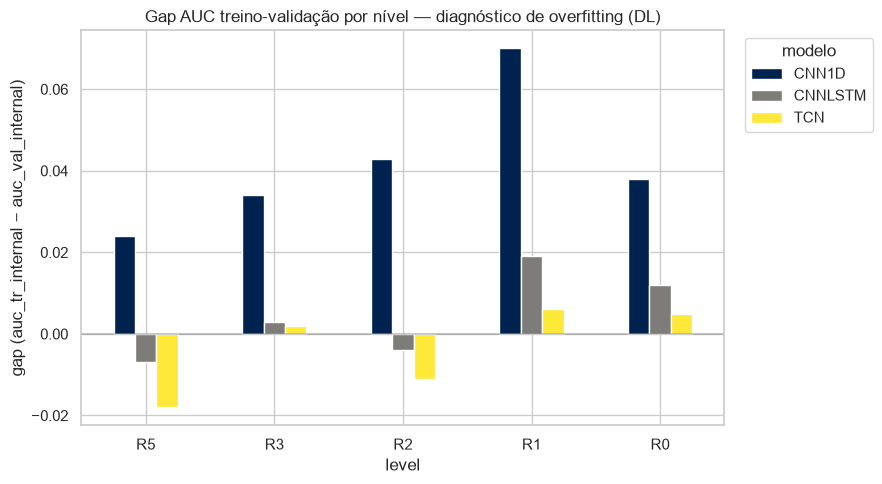

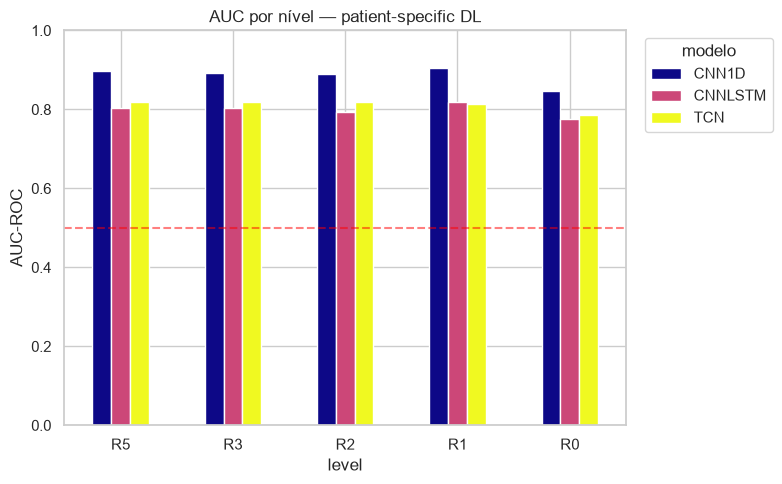

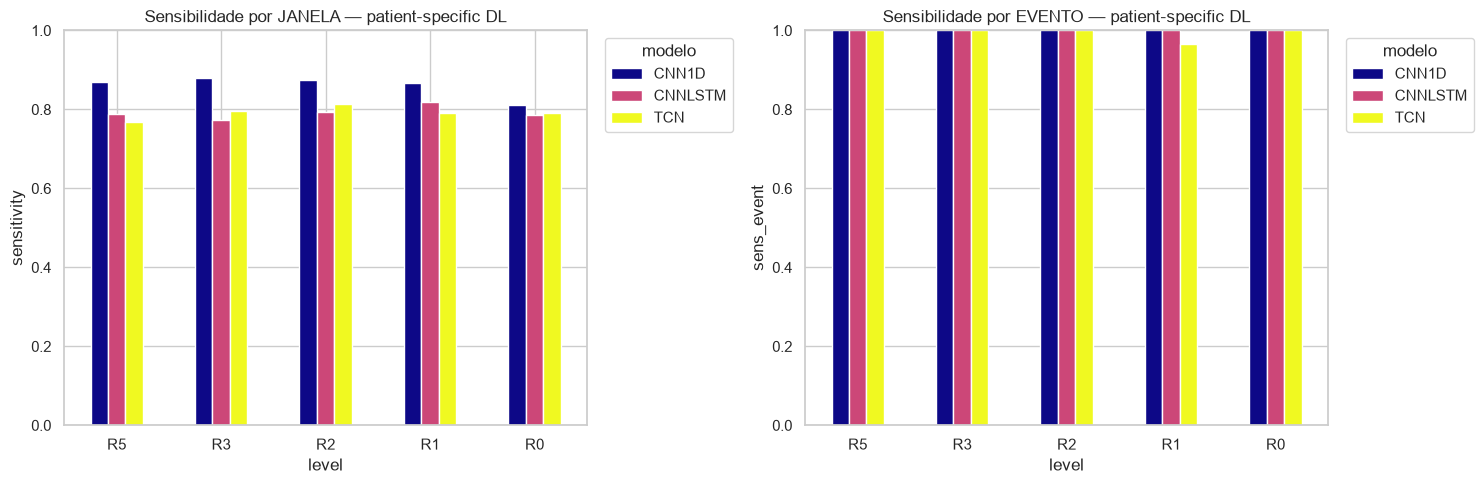

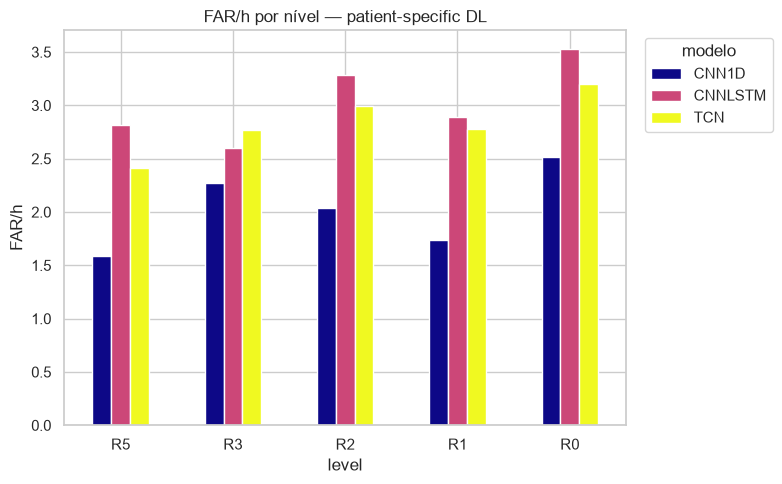


AUC médio geral: 0.830


In [17]:
if os.path.exists(CSV_PS_DL):
    df_dl = pd.read_csv(CSV_PS_DL)
    MAIN = ['auc_roc','sensitivity','specificity','sens_event','far_event_h']

    print('Resumo por dataset, nível e modelo:')
    print('(sensitivity = sensibilidade por janela/amostra; sens_event = sensibilidade por evento,')
    print(' depende da regra de detecção N_CONSEC — basta 1 detecção dentro do evento para contar)')
    ipd.display(df_dl.groupby(['level','dataset','model'])[MAIN].mean().round(3))

    print('\nImpacto da redução de canais:')
    ipd.display(df_dl.groupby('level')[MAIN].mean().reindex(LEVELS).round(3))

    print('\nComparação entre modelos DL:')
    ipd.display(df_dl.groupby('model')[MAIN].mean().round(3))

    # ── Diagnóstico de overfitting: gap AUC treino-validação ──
    # Medido na melhor época (early stopping), no mesmo split por bloco
    # temporal usado no Notebook 3.5 (ML) — tabela comparável entre os dois.
    # Impressa separadamente das figuras, sem sobrepor a visualização.
    if 'overfit_gap' in df_dl.columns:
        print('\nDiagnóstico de overfitting — gap AUC treino-validação (split por bloco temporal):')
        print('(gap = auc_tr_internal - auc_val_internal, na melhor época; compare com a tabela equivalente do NB3.5)')
        gap_tbl = df_dl.groupby('model')[['auc_tr_internal','auc_val_internal','overfit_gap']].mean().round(3)
        ipd.display(gap_tbl)

        gap_by_level = df_dl.groupby(['level','model'])['overfit_gap'].mean().unstack().reindex(LEVELS).round(3)
        print('\nGap por nível e modelo:')
        ipd.display(gap_by_level)

        fig, ax = plt.subplots(figsize=(9,5))
        gap_by_level.plot(kind='bar', ax=ax, colormap='cividis')
        ax.axhline(0, color='gray', ls='-', alpha=0.4)
        ax.set_title('Gap AUC treino-validação por nível — diagnóstico de overfitting (DL)')
        ax.set_ylabel('gap (auc_tr_internal − auc_val_internal)')
        ax.legend(title='modelo', bbox_to_anchor=(1.02, 1), loc='upper left'); ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'ps_dl_overfit_gap.png'), dpi=140, bbox_inches='tight')
        plt.show()

    # Figura 1: AUC por nível (separada, legenda ao lado do gráfico)
    fig, ax = plt.subplots(figsize=(8,5))
    piv = df_dl.groupby(['level','model'])['auc_roc'].mean().unstack().reindex(LEVELS)
    piv.plot(kind='bar', ax=ax, colormap='plasma')
    ax.axhline(0.5, color='red', ls='--', alpha=0.5)
    ax.set_title('AUC por nível — patient-specific DL')
    ax.set_ylabel('AUC-ROC'); ax.set_ylim(0,1)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='modelo', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,'ps_dl_auc_por_nivel.png'), dpi=140, bbox_inches='tight')
    plt.show()

    # Figura 1b: sensibilidade por janela vs por evento (separadas: a por evento
    # é generosa por construção — basta 1 acerto dentro do evento para contar)
    fig, axes = plt.subplots(1, 2, figsize=(15,5))
    piv_sw = df_dl.groupby(['level','model'])['sensitivity'].mean().unstack().reindex(LEVELS)
    piv_sw.plot(kind='bar', ax=axes[0], colormap='plasma')
    axes[0].set_title('Sensibilidade por JANELA — patient-specific DL')
    axes[0].set_ylabel('sensitivity'); axes[0].set_ylim(0,1); axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='modelo', bbox_to_anchor=(1.02,1), loc='upper left')
    piv_se = df_dl.groupby(['level','model'])['sens_event'].mean().unstack().reindex(LEVELS)
    piv_se.plot(kind='bar', ax=axes[1], colormap='plasma')
    axes[1].set_title('Sensibilidade por EVENTO — patient-specific DL')
    axes[1].set_ylabel('sens_event'); axes[1].set_ylim(0,1); axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='modelo', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,'ps_dl_sensibilidade_janela_vs_evento.png'), dpi=140, bbox_inches='tight')
    plt.show()

    # Figura 2: FAR/h por nível (separada, legenda ao lado do gráfico)
    fig, ax = plt.subplots(figsize=(8,5))
    piv2 = df_dl.groupby(['level','model'])['far_event_h'].mean().unstack().reindex(LEVELS)
    piv2.plot(kind='bar', ax=ax, colormap='plasma')
    ax.set_title('FAR/h por nível — patient-specific DL')
    ax.set_ylabel('FAR/h'); ax.tick_params(axis='x', rotation=0)
    ax.legend(title='modelo', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,'ps_dl_far_por_nivel.png'), dpi=140, bbox_inches='tight')
    plt.show()

    print(f'\nAUC médio geral: {df_dl["auc_roc"].mean():.3f}')
else:
    print('Execute a seção 4 primeiro.')

## 6. Curvas de loss e detecção de overfitting

In [18]:
def plot_training_curves(hist_store, n_exemplos=6):
    '''Plota curvas de loss e AUC de treino vs. validação para detectar overfitting.'''
    keys = list(hist_store.keys())[:n_exemplos]
    if not keys: print('Sem histórico de treino.'); return
    fig, axes = plt.subplots(2, len(keys), figsize=(4*len(keys), 7))
    if len(keys)==1: axes = axes.reshape(2,1)
    for j, k in enumerate(keys):
        h = hist_store[k]
        ep = range(1, len(h['loss_tr'])+1)
        axes[0,j].plot(ep, h['loss_tr'], label='treino')
        axes[0,j].plot(ep, h['loss_val'], label='validação')
        axes[0,j].set_title(k.replace('_',' '), fontsize=8)
        axes[0,j].set_ylabel('Loss'); axes[0,j].legend(fontsize=7)
        axes[1,j].plot(ep, h['auc_tr'], label='treino')
        axes[1,j].plot(ep, h['auc_val'], label='validação')
        axes[1,j].set_ylabel('AUC'); axes[1,j].set_xlabel('época')
        axes[1,j].legend(fontsize=7); axes[1,j].set_ylim(0,1)
    plt.suptitle('Curvas de treino — detecção de overfitting\n'
                 '(divergência entre treino e validação indica overfitting)',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR,'ps_dl_training_curves.png'), dpi=140, bbox_inches='tight')
    plt.show()

if hist_store:
    plot_training_curves(hist_store)
else:
    print('Histórico de treino não disponível (notebook reiniciado?).')
    print('Re-rode a seção 4 para gerar as curvas.')

Histórico de treino não disponível (notebook reiniciado?).
Re-rode a seção 4 para gerar as curvas.


## 7. Grad-CAM e Attention Maps


CHBMIT/R5 — modelo vencedor: CNN1D


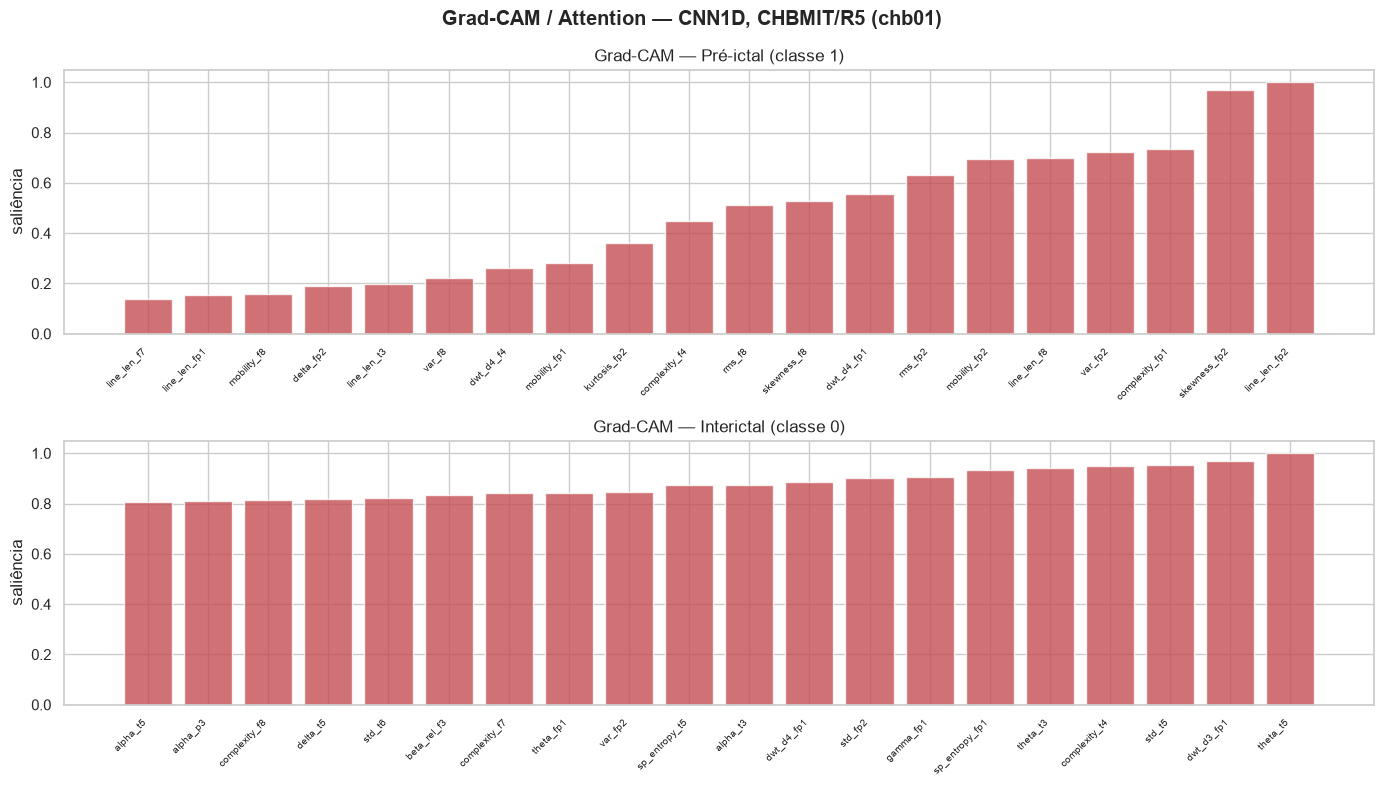


Siena/R5 — modelo vencedor: CNN1D


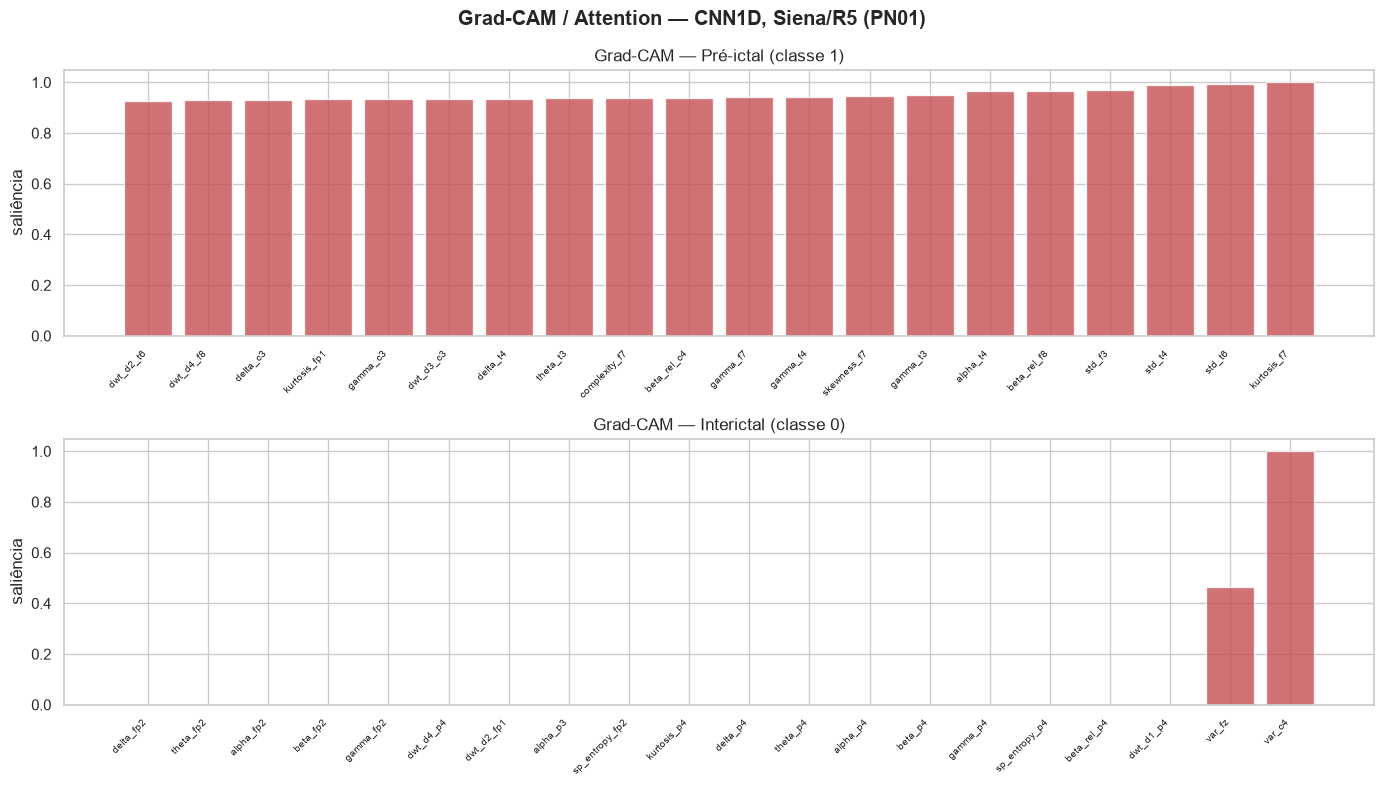


Mendeley/R5 — modelo vencedor: CNN1D


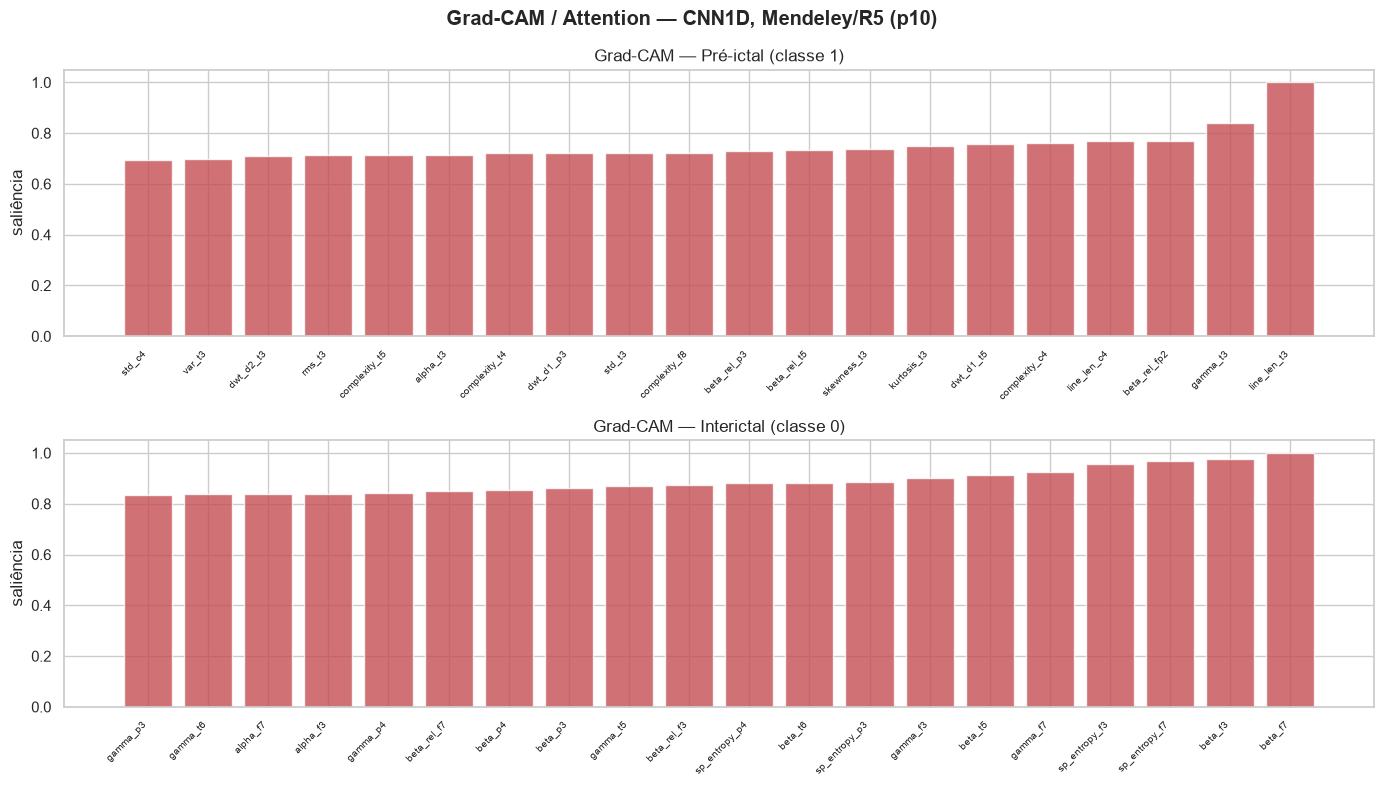


SeizeIT2/R0 — modelo vencedor: CNN1D


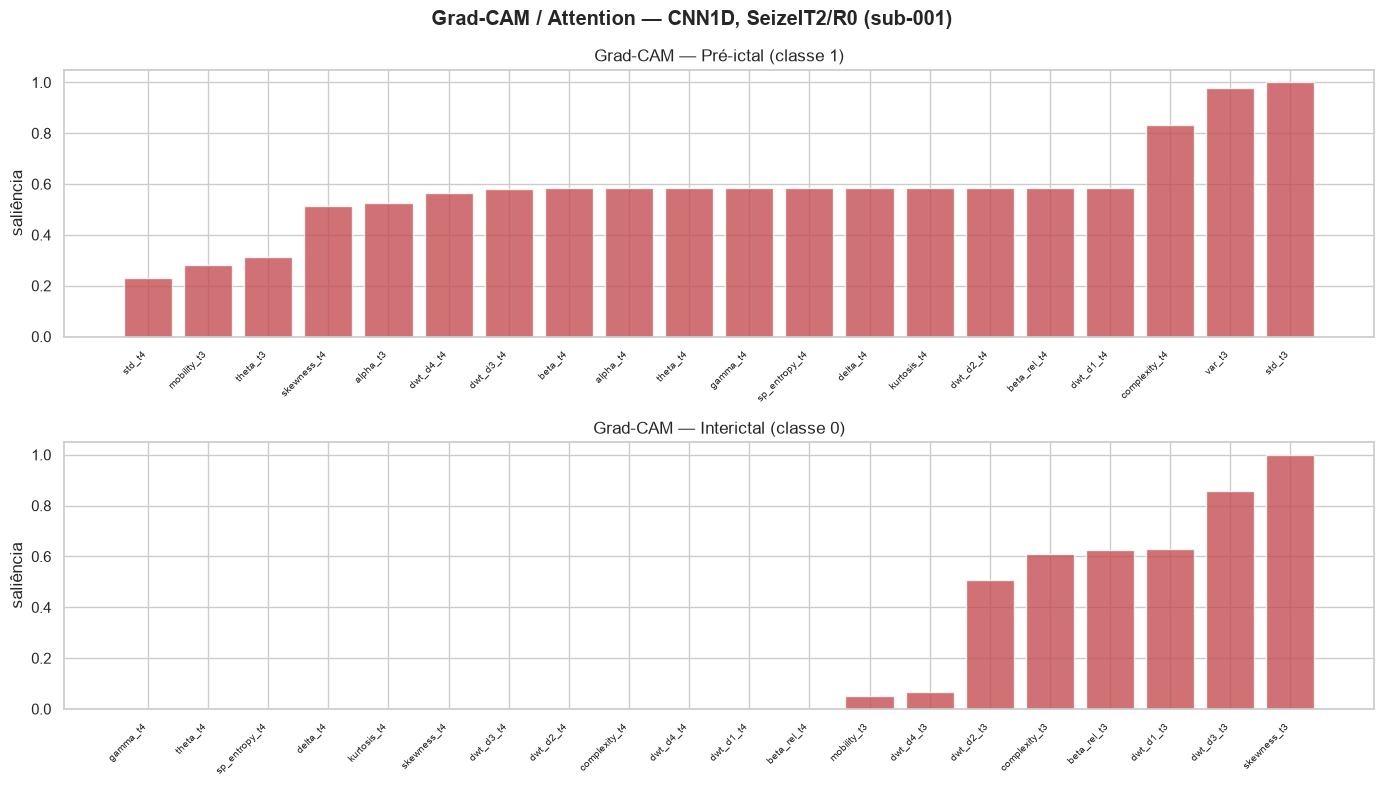

In [19]:
def gradcam_1d(model, x_input, target_class=1):
    '''Grad-CAM 1D: importância de cada posição da entrada para a predição.

    A saída do modelo é um único logit (classificação binária: logit alto
    = pré-ictal, logit baixo = interictal). Para a classe 1, o alvo do
    backward é o próprio logit (maximizar = mais evidência de pré-ictal).
    Para a classe 0, o alvo correto é o NEGATIVO do logit — isso refaz o
    grafo computacional já mirando na direção certa, em vez de calcular o
    gradiente da classe 1 e só inverter o sinal depois (abordagem antiga,
    mais frágil: em modelos fracos o resultado invertido cai todo abaixo
    de zero e o CAM final fica vazio sem nenhum aviso).

    Mesmo com o alvo corrigido, um modelo genuinamente mal ajustado para
    aquela combinação dataset/nível pode produzir um CAM degenerado (todo
    zero). Nesse caso a função retorna (None, True) — "degenerado" — em
    vez de um vetor de zeros silencioso, para a chamada externa poder
    avisar o usuário explicitamente em vez de mostrar um gráfico vazio.

    Retorna (vetor_de_saliência ou None, degenerado: bool).
    '''
    model.eval()
    x_t = torch.FloatTensor(x_input).unsqueeze(0).to(DEVICE)
    x_t.requires_grad_(True)

    model.zero_grad()
    out = model(x_t)
    target = out if target_class == 1 else -out
    target.backward()

    if model.gradients is None or model.activations is None:
        return None, True

    grads = model.gradients[0].cpu().detach().numpy()   # (C, L)
    acts  = model.activations[0].cpu().detach().numpy() # (C, L)

    weights = grads.mean(axis=1)                         # (C,)
    cam = (weights[:, None] * acts).sum(axis=0)           # (L,)
    cam = np.maximum(cam, 0)

    if cam.max() <= 1e-12:
        return None, True   # degenerado: modelo sem sinal discriminativo aqui

    cam = cam / cam.max()
    from scipy.ndimage import zoom
    cam_full = zoom(cam, x_input.shape[0] / cam.shape[0])
    return cam_full, False

def attention_map(model, x_input):
    '''Extrai attention weights do CNN-LSTM.'''
    model.eval()
    x_t = torch.FloatTensor(x_input).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _ = model(x_t)
    if model.attn_weights is None:
        return None
    return model.attn_weights[0].numpy()  # (n_features,)

def run_interpretability_dl(dataset, level='R5'):
    '''Grad-CAM e Attention para o modelo vencedor no dataset/nível.'''
    if not os.path.exists(CSV_PS_DL): print('Execute seção 4 primeiro.'); return
    df_dl = pd.read_csv(CSV_PS_DL)
    sub = df_dl[(df_dl['dataset']==dataset)&(df_dl['level']==level)]
    if sub.empty: print(f'Sem dados para {dataset}/{level}.'); return

    model_name = sub.groupby('model')['auc_roc'].mean().idxmax()
    print(f'{dataset}/{level} — modelo vencedor: {model_name}')

    # Usar o primeiro paciente com dados disponíveis
    pat = None
    for p in PATIENTS.get(dataset,[]):
        X, y = load_feat(dataset, p, level, 'test')
        if X is not None and y.sum() > 0: pat = p; break
    if pat is None: print('Sem paciente com dados de teste.'); return

    X_tr, y_tr = load_feat(dataset, pat, level, 'train')
    X_te, y_te = load_feat(dataset, pat, level, 'test')
    sc = StandardScaler(); X_tr_sc=sc.fit_transform(X_tr); X_te_sc=sc.transform(X_te)

    n_feat = X_tr_sc.shape[1]
    model = get_model_dl(model_name, n_feat).to(DEVICE)

    idx_t, idx_v = block_train_val_split(y_tr, val_frac=VAL_FRAC, seed=42)
    model, _, _ = train_model(model, X_tr_sc[idx_t], y_tr[idx_t],
                               X_tr_sc[idx_v], y_tr[idx_v])
    model.eval()

    # Pegar 1 amostra pré-ictal e 1 interictal do teste
    idx_pre   = np.where(y_te==1)[0]
    idx_inter = np.where(y_te==0)[0]
    if len(idx_pre)==0 or len(idx_inter)==0: return

    samples = {
        'Pré-ictal (classe 1)': X_te_sc[idx_pre[0]],
        'Interictal (classe 0)': X_te_sc[idx_inter[0]],
    }

    FEAT_NAMES_BASE = ['std','var','rms','line_len','mobility','skewness','kurtosis',
                       'delta','theta','alpha','beta','gamma','sp_entropy','beta_rel',
                       'dwt_d1','dwt_d2','dwt_d3','dwt_d4','complexity']
    CHANNEL_SETS = {'R5':['fp1','fp2','f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4','p3','p4'],
                    'R3':['f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4'],
                    'R2':['f7','f3','fz','f4','f8','t3','t4','t5','t6'],
                    'R1':['t3','t4','t5','t6'], 'R0':['t3','t4']}
    feat_names = [f'{f}_{ch}' for ch in CHANNEL_SETS[level] for f in FEAT_NAMES_BASE]

    n_plots = len(samples)
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4*n_plots))
    if n_plots==1: axes=[axes]
    fig.suptitle(f'Grad-CAM / Attention — {model_name}, {dataset}/{level} ({pat})',
                 fontweight='bold')

    for ax, (label, x_inp) in zip(axes, samples.items()):
        target_cls = 1 if 'Pré-ictal' in label else 0
        degenerate = False

        if model_name == 'CNN1D':
            saliency, degenerate = gradcam_1d(model, x_inp, target_class=target_cls)
            title_suffix = 'Grad-CAM'
        elif model_name == 'CNNLSTM':
            saliency = attention_map(model, x_inp)
            if saliency is None:
                saliency = None; degenerate = True
            title_suffix = 'Attention'
        else:
            # TCN: gradiente do alvo certo em relação à entrada (mesmo
            # princípio do Grad-CAM acima — negativa o logit para a classe 0
            # antes do backward, em vez de inverter o sinal depois).
            x_t = torch.FloatTensor(x_inp).unsqueeze(0).to(DEVICE); x_t.requires_grad_(True)
            out = model(x_t)
            target = out if target_cls == 1 else -out
            target.backward()
            grad = x_t.grad[0].cpu().detach().numpy()
            saliency = np.maximum(grad, 0)
            if saliency.max() <= 1e-12:
                saliency = None; degenerate = True
            else:
                saliency = saliency / saliency.max()
            title_suffix = 'Gradiente de saliência'

        if degenerate or saliency is None:
            # Saliência degenerada: o modelo não produziu sinal discriminativo
            # válido para esta classe nesta combinação dataset/nível — sintoma
            # de um modelo fraco aqui (ex: AUC baixo), não um bug de plotagem.
            # Mostrar isso explicitamente em vez de um painel vazio sem explicação.
            ax.text(0.5, 0.5,
                    'Saliência degenerada nesta combinação\n'
                    '(modelo com baixo poder discriminativo para esta classe —\n'
                    'ver AUC desta combinação na tabela de resultados)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=10, color='#888888', style='italic')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f'{title_suffix} — {label} (degenerado)')
            continue

        # Redimensionar para o número de features se necessário
        if len(saliency) != len(feat_names):
            from scipy.ndimage import zoom
            saliency = zoom(saliency, len(feat_names)/len(saliency))

        top_idx = np.argsort(saliency)[-20:]
        ax.bar(range(len(top_idx)), saliency[top_idx], color='#C44E52', alpha=0.8)
        ax.set_xticks(range(len(top_idx)))
        ax.set_xticklabels([feat_names[i] for i in top_idx], rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{title_suffix} — {label}')
        ax.set_ylabel('saliência')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'ps_dl_gradcam_{dataset}_{level}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

# Rodar para cada dataset
for ds in ['CHBMIT','Siena','Mendeley']:
    print(f'\n{"="*50}')
    run_interpretability_dl(ds, 'R5')
print(f'\n{"="*50}')
run_interpretability_dl('SeizeIT2', 'R0')

## 8. Encerramento

Resultados em `data/results/patient_specific_dl.csv` e figuras em `data/results/figures/`.

Próximo: Notebook 5 — cenários A, B e C com Deep Learning.